# TTFM Inference Quick Start

This notebook loads the TTFM pipeline from the Hugging Face Hub and runs a forecast on a sample CSV. Pre-trained weights are at [bekzatajan/ttfm](https://huggingface.co/bekzatajan/ttfm/tree/main). To prepare FNSPID evaluation data, see the [Preparing FNSPID evaluation data](https://github.com/bekzatajan/synthefy-ttfm#preparing-fnspid-evaluation-data) section in the README.

**Requirements:** Install the package from the repo root (`uv sync`). A vLLM server must be running and `VLLM_BASE_URL` / `VLLM_MODEL` set (default URL: http://localhost:8004/v1, default model: openai/gpt-oss-120b); otherwise you can pass pre-computed `summaries` to `predict()`.

In [1]:
%matplotlib inline
import warnings
# Suppress tqdm's IProgress warning in Jupyter when ipywidgets isn't installed
warnings.filterwarnings("ignore", message="IProgress not found")

import os
import numpy as np
from ttfmeval import TTFMPipeline

pipeline = TTFMPipeline.from_pretrained(
    "bekzatajan/ttfm",
    device="cuda",  # or "cpu"
)

Loading Chronos-2 on device: cuda
Loading TimesFM 2.5...
Downloaded.
Compiling model...
TimesFM 2.5 loaded
Initialized univariate models: chronos, timesfm (prophet on-demand)


## Load sample data

Load a local CSV with columns `t`, `y_t`, `text`. We use the first `seq_len` rows as context for one prediction. To prepare FNSPID data, run `bash scripts/prepare_fnspid.sh` from the repo root (see README).

In [3]:
import pandas as pd

seq_len = 64
pred_len = 16

# Load a local CSV with columns: t, y_t, text
# To prepare FNSPID data: bash scripts/prepare_fnspid.sh (see README)
csv_path = "../data/fnspid/output/adbe_with_text.csv"  # adjust path to your data
df = pd.read_csv(csv_path)

# Use first seq_len rows as context (columns: t, y_t, text)
df = df.head(seq_len)
context = df["y_t"].values.astype(np.float32).reshape(1, -1)  # (1, seq_len)
text = [df["text"].fillna("").astype(str).tolist()]  # list of one list of seq_len strings

forecast = pipeline.predict(context, text, pred_len=pred_len)
print(f"Forecast shape: {forecast.shape}")  # (1, pred_len, 1)

Summarization error: Connection error.
Forecast shape: torch.Size([1, 16, 1])


## Plot context and forecast

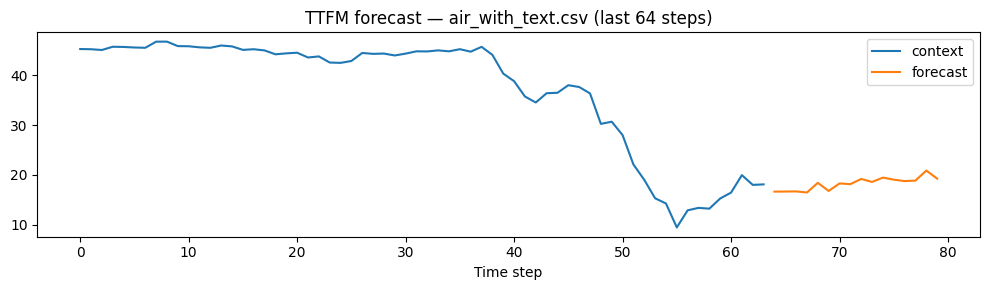

In [5]:
import matplotlib.pyplot as plt

ctx = context[0]
pred = forecast[0, :, 0].detach().cpu().numpy()

plt.figure(figsize=(10, 3))
plt.plot(np.arange(len(ctx)), ctx, label="context")
plt.plot(np.arange(len(ctx), len(ctx) + len(pred)), pred, label="forecast")
plt.legend()
plt.xlabel("Time step")
plt.title("TTFM forecast — air_with_text.csv (last {} steps)".format(seq_len))
plt.tight_layout()
plt.show()